In [1]:
# 初始设置和导入
import os
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import h5py
import numpy as np
import re
import json
from pathlib import Path
from scipy.stats import gmean
from matplotlib.patches import Patch

print("环境设置完成")

环境设置完成


In [ ]:
# 将配置拆分为更清晰的结构
config = {
    "applications": [
        {"name": "SSSP", "weighted": True},
        {"name": "SSWP", "weighted": True},
        {"name": "BFS", "weighted": False},
        {"name": "CC", "weighted": False},
    ],
    "datasets": {
        "roadNet-CA-ungraph": {
            "source": 0, "direction": "-s",
            "recordBatch": {"SSSP": (7, 300), "SSWP": (7, 1), "BFS": (7, 1), "CC": (7, 300)}
        },
        "delaunay-n21": {
            "source": 1, "direction": "-s",
            "recordBatch": {"SSSP": (1, 300), "SSWP": (1, 1), "BFS": (1, 1), "CC": (1, 300)}
        },
        "venturiLevel3": {
            "source": 1, "direction": "-s",
            "recordBatch": {"SSSP": (1, 300), "SSWP": (1, 1), "BFS": (1, 1), "CC": (1, 30)}
        },
        "hugetrace-00000": {
            "source": 1, "direction": "-s",
            "recordBatch": {"SSSP": (15, 300), "SSWP": (15, 1), "BFS": (15, 1), "CC": (15, 10000)}
        },
        "apache2": {
            "source": 1, "direction": "-s",
            "recordBatch": {"SSSP": (1, 300), "SSWP": (1, 1), "BFS": (1, 1), "CC": (1, 300)}
        },
        "ecology1": {
            "source": 1, "direction": "-s",
            "recordBatch": {"SSSP": (7, 300), "SSWP": (7, 1), "BFS": (8, 1), "CC": (1, 300)}
        }
    },
    "hardware": {
        "batchSizes": [100000],
        "deleteRatios": [0.1],
        "cores_configs": [(16, 6)],
        "type": "ooo_nuca",
        "bank_size": 0.5 * 1024 * 1024,
        "buckets": 128,
    },
    "prefetch": {
        "graphPrefetchEntries": [(4, 32), (8, 64)],
        "PDELatencies": [2, 8, 16, 27],
    },
    "paths": {
        "DATASET_ROOT": Path("/home/xuanyi/research/graph/graphbolt/inputs"),
        "ROOT": Path("/home/xuanyi/research/simulator/DAMOV/simulator"),
        "TEMPLATE_DIR": Path("/home/xuanyi/research/simulator/DAMOV/simulator/templates"),
        "SOFTWARE_ROOT" : Path("/home/xuanyi/research/graph/graphbolt/base_kickstarter/result"),
        "FIGURE_DIR": Path("/home/xuanyi/research/simulator/DAMOV/results/"),
    }
}

In [3]:
# 工具函数定义
def convert_config_to_json(js):
    """转换配置文件为JSON格式"""
    js = '{\n%s}' % js
    replacements = [
        (' = ', ' : '), (';\n', ',\n'), (r',\n(\s*)}', r'\n\1}'),
        (r'(\S+) : ', r'"\1" : '), (r'(\d+)L', r'\1')
    ]
    for pattern, repl in replacements:
        js = re.sub(pattern, repl, js)
    return js

def safe_extract(func, default=0):
    """安全提取数据的装饰器"""
    def wrapper(*args, **kwargs):
        try:
            return func(*args, **kwargs)
        except Exception as e:
            print(f"Warning: {func.__name__} failed: {e}")
            return default
    return wrapper

import numpy as np
from functools import wraps

def safe_extract(func):
    """统一异常捕获，避免函数出错"""
    @wraps(func)
    def wrapper(*args, **kwargs):
        try:
            return func(*args, **kwargs)
        except Exception:
            return 0
    return wrapper


@safe_extract
def get_execution_time(config, dataset):
    phaseLength = int(config['sim']['phaseLength'])
    phases = int(dataset[-1]['phase'])
    return int(phaseLength * (phases + 1))


@safe_extract
def get_total_load_stall_time(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['loadStallsTotal'])


@safe_extract
def get_total_graph_load_stall_time(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['graphLoadStallsTotal'])


@safe_extract
def get_graph_stall_proportion(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.min(dataset[-1][core_name]['graphLoadStallsTotal'] / dataset[-1][core_name]['loadStallsTotal'])


@safe_extract
def get_total_execution_time(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['cycles'])


@safe_extract
def get_total_hit_num(dataset, cache):
    return np.sum(dataset[-1][cache]['hGETS']) + np.sum(dataset[-1][cache]['hGETX'])


@safe_extract
def get_total_miss_num(dataset, cache):
    return (np.sum(dataset[-1][cache]['mGETS']) +
            np.sum(dataset[-1][cache]['mGETXIM']) +
            np.sum(dataset[-1][cache]['mGETXSM']))


@safe_extract
def get_total_graph_hit_num(dataset, cache):
    return np.sum(dataset[-1][cache]['hGraphGETS']) + np.sum(dataset[-1][cache]['hGraphGETX'])


@safe_extract
def get_total_graph_miss_num(dataset, cache):
    return (np.sum(dataset[-1][cache]['mGraphGETS']) +
            np.sum(dataset[-1][cache]['mGraphGETXIM']) +
            np.sum(dataset[-1][cache]['mGraphGETXSM']))


@safe_extract
def get_vertex_updated_times(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['propertyStore'])


@safe_extract
def get_data_access_nums(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['edgeLoad'])


@safe_extract
def get_average_load_latency(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.average(dataset[-1][core_name]['averageLoadLatency'])


@safe_extract
def get_average_graph_load_latency(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.min(dataset[-1][core_name]['averageGraphLoadLatency'])


@safe_extract
def get_total_graph_load_latency(config, dataset):
    core_name, = config['sys']['cores'].keys()
    return np.sum(dataset[-1][core_name]['graphDataLoadLatency'])


@safe_extract
def get_effective_access_nums(filename):
    start = False
    with open(filename, 'r') as f:
        for line in f:
            if "ROI begin" in line:
                start = True
            if start and "Effective propagation number in this batch" in line:
                return float(line.split(":")[1].strip())
    return 0


print("工具函数定义完成")

工具函数定义完成


In [4]:
def parse_mcpat_energy(file_path):
    # 分类定义（提前定义好）
    categories = {
        "Core": [
            "core-core", "core-ifetch", "core-alu", "core-int",
            "core-fp", "core-mem", "core-other"
        ],
        "L1": ["icache", "dcache"],
        "L2": ["l2"],
        "LLC": ["l3"],
        "Memory": ["dram"],
    }

    energy_data = {}
    try:
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line or ("energy" in line and "Energy" in line):
                    continue  # 跳过空行和表头

                parts = [p for p in line.split() if p]
                if len(parts) < 4:
                    continue

                component = parts[0]
                try:
                    energy = float(parts[3].replace('J', ''))
                except (ValueError, IndexError):
                    energy = 0.0  # 如果解析失败，设为 0
                energy_data[component] = energy

    except (FileNotFoundError, IOError):
        energy_data = {}

    # 分类能耗累加
    category_energy = {}
    for category, components in categories.items():
        total = sum(energy_data.get(comp, 0.0) for comp in components)
        category_energy[category] = total

    return category_energy

In [5]:
# 简化的数据收集函数（基于framework和hardware区分配置）
def collect_simulation_data(base_path, framework, hardware):
    """
    收集模拟数据 - 基于framework和hardware区分配置

    Parameters:
    base_path: 基础路径
    framework: 框架名称 (kickstarter, wsgraph)
    hardware: 硬件配置 (L1_64, stride_prefetch, ampm_prefetch, bop_prefetch,
                       imp_prefetch, graph_prefetch_4_32_2, graph_prefetch_with_filter_4_32_2)
    """
    data_records = []

    for app_config in config["applications"]:
        app_name = app_config["name"]

        for dataset_name, dataset_config in config["datasets"].items():
            if app_name not in dataset_config["recordBatch"]:
                continue

            record_batch, delta = dataset_config["recordBatch"][app_name]

            for batch_size in config["hardware"]["batchSizes"]:
                for delete_ratio in config["hardware"]["deleteRatios"]:
                    for cores, mc in config["hardware"]["cores_configs"]:

                        # 构建统计目录路径（与配置生成脚本完全一致）
                        stat_dir = (base_path / framework / hardware / app_name /
                                  dataset_name / str(batch_size) / str(delete_ratio) /
                                  config["hardware"]["type"] / str(cores))

                        if not stat_dir.exists():
                            print(f"目录不存在: {stat_dir}")
                            continue

                        try:
                            # 读取配置文件
                            cfg_file = stat_dir / 'result.out.cfg'
                            if not cfg_file.exists():
                                print(f"配置文件不存在: {cfg_file}")
                                continue

                            with open(cfg_file) as jf:
                                config_data = json.loads(convert_config_to_json(jf.read()))

                            # 读取HDF5数据
                            h5_file = stat_dir / 'result.zsim-ev.h5'
                            if not h5_file.exists():
                                print(f"HDF5文件不存在: {h5_file}")
                                continue

                            with h5py.File(h5_file, 'r') as f:
                                dataset_data = f['stats']['root']

                            # 提取所有指标
                            record = {
                                # 基础信息
                                'Framework': framework,
                                'Hardware': hardware,
                                'Application': app_name,
                                'Dataset': dataset_name,
                                'BatchSize': batch_size,
                                'DeleteRatio': delete_ratio,
                                'Cores': cores,
                                'MemoryControllers': mc,
                                'RecordBatch': record_batch,
                                'Delta': delta,

                                # 执行时间相关
                                'ExecutionTime': get_execution_time(config_data, dataset_data),
                                'TotalExecutionCycles': get_total_execution_time(config_data, dataset_data),

                                # 负载相关
                                'UpdatedTimes': get_vertex_updated_times(config_data, dataset_data),
                                'AccessTimes': get_data_access_nums(config_data, dataset_data),

                                # 延迟相关
                                'AvgLoadLatency': get_average_load_latency(config_data, dataset_data),
                                'AvgGraphLoadLatency': get_average_graph_load_latency(config_data, dataset_data),
                                'TotalGraphLoadLatency': get_total_graph_load_latency(config_data, dataset_data),

                                # 停顿相关
                                'TotalLoadStall': get_total_load_stall_time(config_data, dataset_data),
                                'TotalGraphLoadStall': get_total_graph_load_stall_time(config_data, dataset_data),
                                'GraphStallProportion': get_graph_stall_proportion(config_data, dataset_data),

                                # 能耗
                                'Energy': parse_mcpat_energy(stat_dir / "mcpat.log")
                            }

                            # 添加缓存统计
                            cache_stats = {}
                            for cache_level in ['l1d', 'l3']:
                                try:
                                    total_accesses = (get_total_hit_num(dataset_data, cache_level) +
                                                     get_total_miss_num(dataset_data, cache_level))
                                    graph_accesses = (get_total_graph_hit_num(dataset_data, cache_level) +
                                                     get_total_graph_miss_num(dataset_data, cache_level))

                                    if total_accesses > 0:
                                        cache_stats[f'{cache_level}_TotalMissRate'] = (
                                            get_total_miss_num(dataset_data, cache_level) / total_accesses)
                                        cache_stats[f'{cache_level}_GraphMissRate'] = (
                                            get_total_graph_miss_num(dataset_data, cache_level) / graph_accesses if graph_accesses > 0 else 0)
                                        cache_stats[f'{cache_level}_GraphAccessProportion'] = (
                                            graph_accesses / total_accesses)
                                except:
                                    pass

                            record.update(cache_stats)

                            data_records.append(record)
                            # print(f"✓ 处理完成: {framework}/{hardware}/{app_name}/{dataset_name}")

                        except Exception as e:
                            print(f"✗ 处理失败: {stat_dir} - {e}")

    return pd.DataFrame(data_records)

# 批量收集所有配置的数据
def collect_all_configurations(base_path):
    """
    收集所有配置的数据
    """
    all_data_frames = []

    # 所有配置组合
    configurations = [
        # Kickstarter 配置
        ("kickstarter", "base"),
        ("kickstarter", "L1_64"),
        ("kickstarter", "stride_prefetch"),
        # ("kickstarter", "ampm_prefetch"),
        ("kickstarter", "bop_prefetch"),
        ("kickstarter", "imp_prefetch"),
        ("kickstarter", "graph_prefetch_4_32_2"),
        ("kickstarter", "graph_prefetch_with_filter_4_32_2"),

        # WSGraph 配置
        ("wsgraph", "base"),
        ("wsgraph", "L1_64"),
        ("wsgraph", "stride_prefetch"),
        # ("wsgraph", "ampm_prefetch"),
        ("wsgraph", "bop_prefetch"),
        ("wsgraph", "imp_prefetch"),
        ("wsgraph", "graph_prefetch_4_32_2"),
        # ("wsgraph", "graph_prefetch_with_filter_4_32_2"),
    ]

    for framework, hardware in configurations:
        # print(f"开始收集 {framework}/{hardware} 数据...")
        df = collect_simulation_data(base_path, framework, hardware)
        if not df.empty:
            all_data_frames.append(df)
            # print(f"✓ 完成 {framework}/{hardware}: {len(df)} 条记录")
        # else:
            # print(f"⚠  {framework}/{hardware}: 无数据")

    if all_data_frames:
        return pd.concat(all_data_frames, ignore_index=True)
    else:
        return pd.DataFrame()

# 特定配置的数据收集
def collect_framework_data(base_path, framework):
    """
    收集特定框架的所有配置数据
    """
    framework_configs = {
        "kickstarter": [
            "L1_64", "stride_prefetch", "ampm_prefetch", "bop_prefetch",
            "imp_prefetch", "graph_prefetch_4_32_2", "graph_prefetch_with_filter_4_32_2"
        ],
        "wsgraph": [
            "L1_64", "stride_prefetch", "ampm_prefetch", "bop_prefetch",
            "imp_prefetch", "graph_prefetch_4_32_2", "graph_prefetch_with_filter_4_32_2"
        ]
    }

    all_data_frames = []
    for hardware in framework_configs.get(framework, []):
        # print(f"开始收集 {framework}/{hardware} 数据...")
        df = collect_simulation_data(base_path, framework, hardware)
        if not df.empty:
            all_data_frames.append(df)
            # print(f"✓ 完成 {framework}/{hardware}: {len(df)} 条记录")

    if all_data_frames:
        return pd.concat(all_data_frames, ignore_index=True)
    else:
        return pd.DataFrame()

if __name__ == "__main__":
    base_dir = Path("/home/xuanyi/research/simulator/DAMOV/paper/zsim_stats")

    # 方式1: 收集所有配置的数据
    print("开始收集所有配置的数据...")
    all_data = collect_all_configurations(base_dir)

    # 方式2: 分别收集不同框架的数据
    # print("开始收集Kickstarter数据...")
    # kickstarter_data = collect_framework_data(base_dir, "kickstarter")
    #
    # print("开始收集WSGraph数据...")
    # wsgraph_data = collect_framework_data(base_dir, "wsgraph")
    #
    # all_data = pd.concat([kickstarter_data, wsgraph_data], ignore_index=True)

    if not all_data.empty:
        # 保存数据
        all_data.to_csv("all_simulation_results.csv", index=False)

        print("数据收集完成！")
        print(f"总共收集了 {len(all_data)} 条记录")
        print(f"包含的配置组合: {all_data[['Framework', 'Hardware']].drop_duplicates().to_string(index=False)}")
    else:
        print("没有收集到任何数据！")

开始收集所有配置的数据...


数据收集完成！
总共收集了 312 条记录
包含的配置组合:   Framework                          Hardware
kickstarter                              base
kickstarter                             L1_64
kickstarter                   stride_prefetch
kickstarter                      bop_prefetch
kickstarter                      imp_prefetch
kickstarter             graph_prefetch_4_32_2
kickstarter graph_prefetch_with_filter_4_32_2
    wsgraph                              base
    wsgraph                             L1_64
    wsgraph                   stride_prefetch
    wsgraph                      bop_prefetch
    wsgraph                      imp_prefetch
    wsgraph             graph_prefetch_4_32_2


In [6]:
def collect_effetive_access_num(dirPath):
    access_num_frame = []
    for app_config in config["applications"]:
        app_name = app_config["name"]

        for dataset_name, dataset_config in config["datasets"].items():
            for batch_size in config["hardware"]["batchSizes"]:
                for delete_ratio in config["hardware"]["deleteRatios"]:
                    for cores, mc in config["hardware"]["cores_configs"]:
                        resultDir = f"{dirPath}/{app_name}/{dataset_name}/{batch_size}/{delete_ratio}/{cores}/"
                        resultFile = os.path.join(resultDir, "result.log")
                        dataAccessNum = get_effective_access_nums(resultFile)
                        access_num_frame.append((app_name, dataset_name, int(batch_size), float(delete_ratio), int(cores), float(dataAccessNum)))
    # 创建 DataFrame
    df = pd.DataFrame(access_num_frame, columns=['Application', 'Dataset', 'Batch Size', "DeleteRatio", "Cores", "AccessTimes"])
    return df

if __name__ == "__main__":
    print("开始收集有效的更新数量...")
    softwareData = collect_effetive_access_num(config["paths"]["SOFTWARE_ROOT"])


开始收集有效的更新数量...


In [7]:
# ==================== 全局样式设置 ====================
# 设置统一的图表尺寸和样式
CHART_CONFIG = {
    # 基础尺寸 (以pt为单位，转换为英寸)
    'single_column_width_pt': 430,      # 单栏宽度
    'pt_to_inch': 1/72,                 # pt转英寸系数

    # 图表尺寸比例
    'height_ratio_single': 0.3,        # 单图高度比例
    'height_ratio_double': 0.26,        # 双图高度比例

    # 图表元素尺寸
    'bar_width': 0.8,                   # 柱状图宽度
    'group_gap': 1,                     # 组间间距
    'line_width': 0.5,                  # 线条宽度
    'font_sizes': {
        'title': 8,
        'axis_label': 8,
        'tick': 8,
        'legend': 8,
        'annotation': 8
    },
    'position' : {
        'annotation' : -0.3
    },
    'colors': {
        # 基础颜色
        'total': '#1f77b4',      # 深蓝色 - 总数据/基准
        'graph': '#ff7f0e',      # 橙色 - 图数据/主要对比
        'other': '#2ca02c',      # 绿色 - 其他数据

        # 扩展颜色 - 用于多个配置对比
        'config1': '#1f77b4',    # 深蓝色 (基准)
        'config2': '#ff7f0e',    # 橙色 (对比1)
        'config3': '#2ca02c',    # 绿色 (对比2)
        'config4': '#d62728',    # 红色 (对比3)
        'config5': '#9467bd',    # 紫色 (对比4)
        'config6': '#8c564b',    # 棕色 (对比5)
        'config7': '#e377c2',    # 粉色 (对比6)
        'config8': '#7f7f7f',    # 灰色 (对比7)

        # 语义颜色
        'kickstarter': '#1f77b4',       # Kickstarter - 蓝色
        'wsgraph': '#ff7f0e',           # WSGraph - 橙色
        'wsgraph_s': '#2ca02c',         # WSGraph-S - 绿色
        'prefetch': '#d62728',          # 预取配置 - 红色
        'base': '#7f7f7f',              # 基础配置 - 灰色

        # 功能颜色
        'improvement': '#2ca02c',       # 改进/优化 - 绿色
        'degradation': '#d62728',       # 性能下降 - 红色
        'neutral': '#7f7f7f',           # 中性 - 灰色

        # 图表元素颜色
        'grid': 'black',
        'grid_alpha': 1,
        'text': 'black',
        'background': 'white'
    }

}

# 计算具体尺寸
def get_figure_size(width_type='single', height_type='single'):
    """获取统一尺寸的图表大小"""
    if width_type == 'single':
        width_pt = CHART_CONFIG['single_column_width_pt']
    else:
        width_pt = CHART_CONFIG['double_column_width_pt']

    width_inch = width_pt * CHART_CONFIG['pt_to_inch']

    if height_type == 'single':
        height_inch = width_inch * CHART_CONFIG['height_ratio_single']
    else:
        height_inch = width_inch * CHART_CONFIG['height_ratio_double']

    return (width_inch, height_inch)

# 设置绘图样式
def setup_plot_style():
    plt.rcParams.update({
        # 字体设置
        'font.family': 'serif',
        'font.serif': 'Times New Roman',
        'font.style': 'normal',
        'font.size' : 8,
        'mathtext.fontset': 'stix',

        # 坐标轴设置
        'axes.edgecolor': '0.15',  # 坐标轴颜色
        'axes.linewidth': 0.8,  # 坐标轴线宽
        'axes.grid': False,  # 显示网格
        'grid.color': '0.9',  # 网格颜色
        'grid.linestyle': ':',  # 网格线型
        'grid.linewidth': 0.5,  # 网格线宽

        # 图形元素设置
        'figure.autolayout': True,  # 自动调整布局
        'figure.dpi': 100,  # 默认DPI
        'figure.facecolor': 'white',  # 图形背景色

        # 刻度设置
        'xtick.direction': 'out',  # x刻度方向
        'ytick.direction': 'out',  # y刻度方向
        'xtick.major.size': 3,  # x刻度长度
        'ytick.major.size': 3,  # y刻度长度

        # 图例设置
        'legend.frameon': True,  # 显示图例边框
        'legend.framealpha': 1,  # 图例不透明度
        'legend.edgecolor': '0.8',  # 图例边框颜色

        # 保存设置
        'savefig.dpi': 300,  # 保存图像DPI
        'savefig.bbox': 'tight',  # 保存时自动调整边界
        'savefig.pad_inches': 0.1  # 保存时内边距
    })

setup_plot_style()

# 数据集映射
dataset_mapping = {
    "roadNet-CA-ungraph": "CA",
    "delaunay-n21": "DL",
    "venturiLevel3": "VL",
    "hugetrace-00000": "HT",
    "apache2": "AP",
    "ecology1": "EC"
}

shortdatasets = ['CA', 'DL', 'VL', 'HT', 'AP', "EC"]
algorithms = ['SSSP', 'SSWP', 'BFS', 'CC']
components = ['Core', 'L1', 'L2', 'LLC', 'Memory']

print("绘图样式设置完成")

绘图样式设置完成


In [8]:
# 数据准备函数
def prepare_cache_data(all_data, framework='kickstarter', hardware='base'):
    """准备缓存分析数据"""
    base_data = all_data[(all_data['Framework'] == framework) & (all_data['Hardware'] == hardware)]

    l1_total_miss_rates = []
    l1_graph_miss_rates = []
    l3_total_miss_rates = []
    l3_graph_miss_rates = []

    for app in algorithms:
        for dataset_full, dataset_short in dataset_mapping.items():
            app_dataset_data = base_data[(base_data['Application'] == app) &
                                       (base_data['Dataset'] == dataset_full)]
            if not app_dataset_data.empty:
                l1_total_miss_rates.append(app_dataset_data['l1d_TotalMissRate'].values[0] * 100)
                l1_graph_miss_rates.append(app_dataset_data['l1d_GraphMissRate'].values[0] * 100)
                l3_total_miss_rates.append(app_dataset_data['l3_TotalMissRate'].values[0] * 100)
                l3_graph_miss_rates.append(app_dataset_data['l3_GraphMissRate'].values[0] * 100)

    # 转换为NumPy数组并计算几何平均数
    l1_total_arr = np.array(l1_total_miss_rates)
    l1_graph_arr = np.array(l1_graph_miss_rates)
    l3_total_arr = np.array(l3_total_miss_rates)
    l3_graph_arr = np.array(l3_graph_miss_rates)

    l1_total = np.append(l1_total_arr, gmean(l1_total_arr/100) * 100)
    l1_graph = np.append(l1_graph_arr, gmean(l1_graph_arr/100) * 100)
    l3_total = np.append(l3_total_arr, gmean(l3_total_arr/100) * 100)
    l3_graph = np.append(l3_graph_arr, gmean(l3_graph_arr/100) * 100)

    return l1_total, l1_graph, l3_total, l3_graph

print("数据准备函数定义完成")


数据准备函数定义完成


In [9]:
class FlexibleSideBySidePlotTemplate:
    """
    灵活并排图显示统一模板（支持每个子图多组bar）
    """

    def __init__(self):
        """初始化模板配置"""
        self.config = CHART_CONFIG

    def create_side_by_side_plot(self, subplot_configs, ncols=2,
                            legend_config=None, save_path=None,
                            share_y=False):
        """
        创建灵活并排图

        Parameters:
        subplot_configs: 子图配置列表，每个子图配置为dict，包含:
            - data: 数据列表，每个元素为一组bar的数据
            - labels: X轴标签
            - title: 子图标题
            - ylabel: Y轴标签
            - colors: 该子图的颜色列表（可选）
            - bar_labels: 该子图的bar标签（可选）
        ncols: 并排的子图列数
        legend_config: 图例配置，包含:
            - labels: 图例标签列表
            - colors: 图例颜色列表
            - position: 图例位置（默认'upper center'）
            - ncol: 图例列数（默认2）
        save_path: 保存路径
        share_y: 是否共用左侧坐标轴（默认 False）
        """
        n_subplots = len(subplot_configs)
        nrows = (n_subplots + ncols - 1) // ncols

        # 使用统一尺寸，根据子图数量调整高度
        fig_size = get_figure_size('single', 'grouped')
        fig_width, fig_height = fig_size
        fig_height = fig_height * (1 + 0.2 * (nrows - 1))

        # ✅ 关键改动：添加 sharey 参数
        fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), sharey=share_y)

        if n_subplots == 1:
            axes = np.array([axes])
        axes = axes.flatten()

        # 绘制每个子图
        for i, (ax, config) in enumerate(zip(axes, subplot_configs)):
            if i < len(subplot_configs):
                self._plot_subplot(ax, config)
            else:
                ax.set_visible(False)

        # ✅ 如果共用Y轴，隐藏除第一列以外的y轴标签
        if share_y:
            for i, ax in enumerate(axes):
                # 只显示每行第一列的Y轴
                if (i % ncols) != 0:
                    ax.set_ylabel("")
                    ax.tick_params(labelleft=False)

        # 添加图例
        if legend_config:
            self._add_legend(fig, legend_config)

        plt.tight_layout()
        if legend_config:
            plt.subplots_adjust(top=0.85 if nrows == 1 else 0.9)

        if save_path:
            fig.savefig(save_path, format='pdf', bbox_inches='tight')

        return fig, axes

    def _plot_subplot(self, ax, config):
        """绘制单个子图（包含几何平均数处理）"""
        data = config.get('data', [])
        labels = config.get('labels', [])
        title = config.get('title', '')
        ylabel = config.get('ylabel', '')
        colors = config.get('colors', [self.config['colors']['graph']])
        bar_labels = config.get('bar_labels', [])
        add_gmean = config.get('add_gmean', False)  # 是否添加几何平均数
        standard_line = config.get('standard_line', False)  # 参考线配置

        bar_width = self.config['bar_width']
        gap = self.config['group_gap']

        # 处理几何平均数
        if add_gmean:
            # 为每组数据计算几何平均数
            data_with_gmean = []
            for data_group in data:
                valid_data = data_group[~np.isnan(data_group)]
                if len(valid_data) > 0:
                    gmean_val = gmean(valid_data)
                    data_with_gmean.append(np.append(data_group, gmean_val))
                else:
                    data_with_gmean.append(np.append(data_group, np.nan))
            data = data_with_gmean
            labels = labels + ["Gmean"]

        n_groups = len(labels)
        n_bars = len(data)

        # 计算位置
        index = np.arange(n_groups) * (bar_width * n_bars + gap)

        # 绘制每组bar
        for bar_idx in range(n_bars):
            bar_color = colors[bar_idx % len(colors)]

            ax.bar(index + bar_idx * bar_width, data[bar_idx], bar_width,
                color=bar_color, edgecolor='black',
                linewidth=self.config['line_width'], alpha=0.8,
                label=bar_labels[bar_idx] if bar_idx < len(bar_labels) else f'Bar {bar_idx+1}')

        # 设置X轴
        ax.set_xticks(index + bar_width * (n_bars - 1) / 2)
        ax.set_xticklabels(labels, rotation=0,
                        fontsize=self.config['font_sizes']['tick'])
        ax.set_xlabel(title, fontsize=self.config['font_sizes']['axis_label'])

        # 设置Y轴
        ax.set_ylabel(ylabel, fontsize=self.config['font_sizes']['axis_label'])

        # 添加参考线
        if standard_line:
            line_value = 1.0
            color = 'black'
            linestyle = '--'
            linewidth = self.config['line_width']
            label = None

            ax.axhline(y=line_value, color=color, linestyle=linestyle,
                    linewidth=linewidth, label=label)

        # # 为几何平均数添加特殊标记
        # if add_gmean:
        #     # 在几何平均数柱状图上添加数值标签
        #     gmean_index = n_groups - 1  # 最后一个位置是几何平均数
        #     for bar_idx in range(n_bars):
        #         gmean_value = data[bar_idx][-1]
        #         if not np.isnan(gmean_value):
        #             x_pos = index[gmean_index] + bar_idx * bar_width + bar_width / 2
        #             y_pos = gmean_value + 0.02 * ax.get_ylim()[1]  # 稍微高于柱状图
        #             ax.text(x_pos, y_pos, f'{gmean_value:.2f}',
        #                 ha='center', va='bottom',
        #                 fontsize=self.config['font_sizes']['annotation'] - 1,
        #                 fontweight='bold')

    def _add_legend(self, fig, legend_config):
        """添加图例"""
        labels = legend_config.get('labels', [])
        colors = legend_config.get('colors', [self.config['colors']['graph']])
        position = legend_config.get('position', 'upper center')
        ncol = legend_config.get('ncol', 2)

        legend_elements = [
            Patch(facecolor=colors[i % len(colors)], edgecolor='black', label=label)
            for i, label in enumerate(labels)
        ]

        fig.legend(handles=legend_elements, loc=position, ncol=ncol,
                  framealpha=1, edgecolor="black",
                  fontsize=self.config['font_sizes']['legend'],
                  bbox_to_anchor=(0.55, 1.05), bbox_transform=fig.transFigure
                  )


5.010814594162585 2.421817943173418


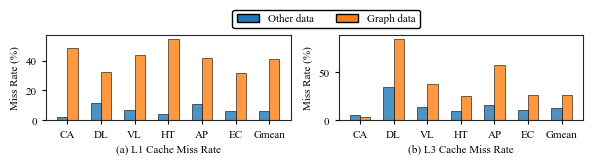

In [10]:
def prepare_sssp_cache_data(all_data, framework='kickstarter', hardware='base'):
    """准备SSSP应用的缓存数据"""
    base_data = all_data[(all_data['Framework'] == framework) &
                        (all_data['Hardware'] == hardware) &
                        (all_data['Application'] == 'SSSP')]

    l1_other, l1_graph, l3_other, l3_graph = [], [], [], []

    for dataset_full, dataset_short in dataset_mapping.items():
        dataset_data = base_data[base_data['Dataset'] == dataset_full]
        if not dataset_data.empty:
            # 计算其他数据的缺失率
            l1_total = dataset_data['l1d_TotalMissRate'].values[0]
            l1_graph_val = dataset_data['l1d_GraphMissRate'].values[0]
            l1_graph_ratio = dataset_data['l1d_GraphAccessProportion'].values[0]
            l1_other_val = (l1_total - l1_graph_val * l1_graph_ratio) / max(0.001, 1 - l1_graph_ratio)

            l3_total = dataset_data['l3_TotalMissRate'].values[0]
            l3_graph_val = dataset_data['l3_GraphMissRate'].values[0]
            l3_graph_ratio = dataset_data['l3_GraphAccessProportion'].values[0]
            l3_other_val = (l3_total - l3_graph_val * l3_graph_ratio) / max(0.001, 1 - l3_graph_ratio)

            l1_other.append(l1_other_val * 100)
            l1_graph.append(l1_graph_val * 100)
            l3_other.append(l3_other_val * 100)
            l3_graph.append(l3_graph_val * 100)

    # 转换为数组并计算几何平均数
    l1_other_arr = np.array(l1_other)
    l1_graph_arr = np.array(l1_graph)
    l3_other_arr = np.array(l3_other)
    l3_graph_arr = np.array(l3_graph)
    print(l1_graph_val/l1_other_val, l3_graph_val/l3_other_val)


    return l1_other_arr, l1_graph_arr, l3_other_arr, l3_graph_arr

# 准备数据
l1_other, l1_graph, l3_other, l3_graph = prepare_sssp_cache_data(all_data)
# 子图配置
subplot_configs = [
    {
        'data': [l1_other, l1_graph],
        'labels': shortdatasets,
        'title': "(a) L1 Cache Miss Rate",
        'ylabel': 'Miss Rate (%)',
        'colors': [CHART_CONFIG['colors']['total'], CHART_CONFIG['colors']['graph']],
        'bar_labels': ['Other data', 'Graph data'],
        'add_gmean': True  # 启用几何平均数
    },
    {
        'data': [l3_other, l3_graph],
        'labels': shortdatasets,
        'title': "(b) L3 Cache Miss Rate",
        'ylabel': 'Miss Rate (%)',
        'colors': [CHART_CONFIG['colors']['total'], CHART_CONFIG['colors']['graph']],
        'bar_labels': ['Other data', 'Graph data'],
        'add_gmean': True  # 启用几何平均数
    }
]

# 图例配置
legend_config = {
    'labels': ['Other data', 'Graph data'],
    'colors': [CHART_CONFIG['colors']['total'], CHART_CONFIG['colors']['graph']],
    'position': 'upper center',
    'ncol': 2
}

# 使用模板
template = FlexibleSideBySidePlotTemplate()
fig, axes = template.create_side_by_side_plot(
    subplot_configs=subplot_configs,
    ncols=2,
    legend_config=legend_config,
    save_path="GraphCacheMiss.pdf",
)

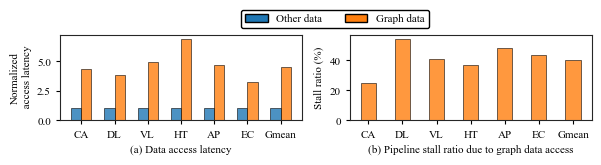

In [12]:

def collect_sssp_latency_stall_data(all_data, framework='kickstarter', hardware='base'):
    # 筛选SSSP应用的基础数据
    base_data = all_data[(all_data['Framework'] == framework) &
                        (all_data['Hardware'] == hardware) &
                        (all_data['Application'] == 'SSSP')]

    latency_ratios = []
    graph_stalls = []

    for dataset_full, dataset_short in dataset_mapping.items():
        dataset_data = base_data[base_data['Dataset'] == dataset_full]
        if not dataset_data.empty:
            # 收集延迟比例数据
            avg_latency = dataset_data['AvgLoadLatency'].values[0]
            avg_graph_latency = dataset_data['AvgGraphLoadLatency'].values[0]
            latency_ratio = avg_graph_latency / avg_latency if avg_latency > 0 else 0
            latency_ratios.append(latency_ratio)

            # 收集停顿比例数据
            graph_stall = dataset_data['GraphStallProportion'].values[0] * 100
            graph_stalls.append(graph_stall)

    # 转换为数组并计算几何平均数
    latency_ratios_arr = np.array(latency_ratios)
    graph_stalls_arr = np.array(graph_stalls)

    return latency_ratios_arr, graph_stalls_arr

# 收集SSSP数据
latency_data, stall_data = collect_sssp_latency_stall_data(all_data)
base_latency = np.ones(len(latency_data))

subplot_configs = [
    {
        'data': [base_latency, latency_data],
        'labels': shortdatasets,
        'title': "(a) Data access latency",
        'ylabel': 'Normalized \n access latency',
        'colors': [CHART_CONFIG['colors']['total'], CHART_CONFIG['colors']['graph']],
        'bar_labels': ['Other data', 'Graph data'],
        'add_gmean': True
    },
    {
        'data': [stall_data],
        'labels': shortdatasets,
        'title': "(b) Pipeline stall ratio due to graph data access",
        'ylabel': 'Stall ratio (%)',
        'colors': [CHART_CONFIG['colors']['graph']],
        'bar_labels': ['Graph stall'],
        'add_gmean': True
    }
]

# 图例配置
legend_config = {
    'labels': ['Other data', 'Graph data'],
    'colors': [CHART_CONFIG['colors']['total'], CHART_CONFIG['colors']['graph']],
    'position': 'upper center',
    'ncol': 2
}

# 使用模板
template = FlexibleSideBySidePlotTemplate()
fig, axes = template.create_side_by_side_plot(
    subplot_configs=subplot_configs,
    ncols=2,
    legend_config=legend_config,
    save_path="Latency_stall.pdf",
)

In [12]:
class GroupedBarPlotTemplate:
    """
    分组柱状图统一模板（支持多维数据，末尾单独添加 Gmean）
    """

    def __init__(self, config):
        """初始化模板配置"""
        self.config = config

    def create_grouped_plot(self, data, category_labels, group_labels, bar_labels=None,
                           colors=None, ylabel='Value', title=None, legend=("upper center", 5),
                           save_path=None, figsize_type='single',
                           add_gmean=False, add_mean=False, mean_annotation=False):
        """
        创建分组柱状图（支持多维数据，Gmean 作为最后单独一组）

        Parameters
        ----------
        data : array
            shape = (n_categories, n_groups, n_bars)
        category_labels : list
            类别标签（如算法名称）
        group_labels : list
            组标签（如数据集名称）
        bar_labels : list
            柱子标签（如数据类型）
        colors : list
            柱子颜色
        ylabel : str
            Y 轴标签
        title : str
            图标题
        save_path : str
            保存路径
        figsize_type : str
            图表大小 ('single' 或 'double')
        add_gmean : bool
            是否在最后添加整体 Gmean
        """
        # 设置默认颜色
        if colors is None:
            colors = [self.config['colors']['graph'], self.config['colors']['total']]

        if bar_labels is None:
            bar_labels = ['Data']

        # 转为 numpy
        data = np.array(data)
        n_categories = len(category_labels)
        n_groups = len(group_labels)
        n_bars = len(bar_labels)

        # 检查维度
        if data.shape != (n_categories, n_groups, n_bars):
            raise ValueError(f"数据形状 {data.shape} 与 (n_categories, n_groups, n_bars) 不匹配")

        # 图表
        fig_size = get_figure_size(figsize_type, 'grouped')
        fig, ax = plt.subplots(figsize=fig_size)

        # 参数
        bar_width = self.config['bar_width']
        group_gap = self.config['group_gap']
        category_gap = self.config['group_gap']

        # 计算 components 位置
        category_positions = []
        start_pos = 0
        for _ in range(n_categories):
            category_width = n_groups * (bar_width * n_bars + group_gap) - group_gap
            category_positions.append((start_pos, start_pos + category_width))
            start_pos += category_width + category_gap

        # 每个 bar 的位置 & ticks
        x_ticks = []
        x_tick_labels = []
        bar_positions = []  # 用于计算 xlim

        for cat_idx in range(n_categories):
            cat_start = category_positions[cat_idx][0]
            for group_idx in range(n_groups):
                group_start = cat_start + group_idx * (bar_width * n_bars + group_gap)

                # group 的 xtick （居中对齐所有 bar）
                group_center = group_start + (n_bars * bar_width) / 2 - bar_width / 2
                x_ticks.append(group_center)
                x_tick_labels.append(group_labels[group_idx])

                # 画每个 bar
                for bar_idx in range(n_bars):
                    value = data[cat_idx, group_idx, bar_idx]
                    position = group_start + bar_idx * bar_width
                    bar_positions.append(position)
                    ax.bar(position, value, bar_width,
                        color=colors[bar_idx % len(colors)],
                        edgecolor='black',
                        linewidth=self.config['line_width'],
                        alpha=0.8,
                        label=bar_labels[bar_idx] if (cat_idx == 0 and group_idx == 0) else None)

        # ====== 在最后绘制 Gmean ======
        flat_data = data.reshape(-1, n_bars)
        if add_gmean:
            gmean_values = gmean(flat_data, axis=0)  # (n_bars,)
        elif add_mean:
            gmean_values = np.nanmean(flat_data, axis=0)  # (n_bars,)

        if add_gmean or add_mean:
            gmean_start = category_positions[-1][1] + category_gap
            gmean_positions = [gmean_start + i * bar_width for i in range(n_bars)]

            bar_positions = bar_positions + gmean_positions
            for bar_idx in range(n_bars):
                ax.bar(gmean_positions[bar_idx], gmean_values[bar_idx], bar_width,
                    color=colors[bar_idx % len(colors)],
                    edgecolor='black',
                    linewidth=self.config['line_width'],
                    alpha=0.8)
                # 在 Gmean 柱子上添加数值标签
                if mean_annotation:
                    ax.text(gmean_positions[bar_idx],       # X 坐标：柱子中心
                        gmean_values[bar_idx],                         # Y 坐标：柱子高度
                        f'{gmean_values[bar_idx]:.3f}',                # 文本内容：保留1位小数 (如 15.3)
                        ha='center',                    # 水平居中
                        va='bottom',                    # 垂直底部对齐 (让文字浮在坐标点上方)
                        fontsize=self.config['font_sizes']['tick'], # 字体大小 (建议用 tick 大小或更小)
                        fontweight='bold',              # 加粗
                        color='black')                  # 颜色

            # Gmean标签像category_labels一样显示在底部
            gmean_center = (gmean_positions[0] + gmean_positions[-1]) / 2
            annotation = "Mean" if add_mean else "Gmean"
            ax.text(gmean_center, self.config['position']['annotation'], annotation,
                    ha='center', va='top',
                    transform=ax.get_xaxis_transform(),
                    fontsize=self.config['font_sizes']['annotation'],
                    fontweight='bold')

        # 设置 X 轴
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels, fontsize=self.config['font_sizes']['tick'])

        # 提取所有柱子位置
        all_bar_positions = np.array(bar_positions)  # 前面所有 components/group/bar 的位置
        if add_gmean or add_mean:
            all_bar_positions = np.concatenate([all_bar_positions, np.array(gmean_positions)])

        # 最左边柱子左边界，最右边柱子右边界
        x_min = all_bar_positions.min() - bar_width
        x_max = all_bar_positions.max() + bar_width

        # 设置横轴范围
        ax.set_xlim([x_min, x_max])

        # 类别标签（大类）
        for cat_idx in range(n_categories):
            cat_start, cat_end = category_positions[cat_idx]
            cat_center = (cat_start + cat_end) / 2
            ax.text(cat_center, self.config['position']['annotation'], category_labels[cat_idx],
                   ha='center', va='top', transform=ax.get_xaxis_transform(),
                   fontsize=self.config['font_sizes']['annotation'],
                   fontweight='bold')

        # 分割线
        for cat_idx in range(1, n_categories):
            divider_pos = category_positions[cat_idx][0] - category_gap
            ax.axvline(divider_pos, color='black', linestyle='--')

        # Y 轴
        ax.set_ylabel(ylabel, fontsize=self.config['font_sizes']['axis_label'])
        ax.set_ylim(0, np.max(data) * 1.2)

        # 图例
        if n_bars > 1:
            fig.legend(loc=legend[0], ncol=legend[1],
                    framealpha=1, edgecolor="black",
                    fontsize=self.config['font_sizes']['legend'])

        if title:
            ax.set_title(title, fontsize=self.config['font_sizes']['title'])

        plt.tight_layout()

        if n_bars > 1:
            plt.subplots_adjust(top=0.85)

        if save_path:
            fig.savefig(save_path, format='pdf', bbox_inches='tight')
        return fig, ax


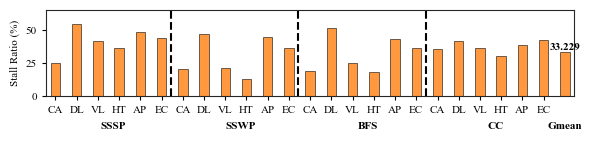

In [13]:
def plot_graph_stall_ratio(all_data, framework='kickstarter', hardware='base', save_path=None):
    """
    使用模板绘制图数据停顿比例
    """

    # 准备数据
    data = []
    for algorithm in algorithms:
        algorithm_data = []
        for dataset_full, dataset_short in dataset_mapping.items():
            if dataset_short in shortdatasets:
                app_dataset_data = all_data[(all_data['Framework'] == framework) &
                                          (all_data['Hardware'] == hardware) &
                                          (all_data['Application'] == algorithm) &
                                          (all_data['Dataset'] == dataset_full)]
                if not app_dataset_data.empty:
                    graph_stall = app_dataset_data['GraphStallProportion'].values[0] * 100
                    algorithm_data.append(graph_stall)
        data.append(algorithm_data)

    data = np.array(data)
    if data.ndim == 2:
        data = data[:, :, np.newaxis]   # (n_categories, n_groups, 1)

    # 使用模板
    template = GroupedBarPlotTemplate(CHART_CONFIG)
    fig, ax = template.create_grouped_plot(
        data=data,
        category_labels=algorithms,
        group_labels=shortdatasets,
        bar_labels=['Graph Stall'],
        colors=[CHART_CONFIG['colors']['graph']],
        ylabel='Stall Ratio (%)',
        add_gmean=True,
        add_mean=False,
        mean_annotation=True,
        save_path=save_path
    )

    return fig, ax

fig, ax = plot_graph_stall_ratio(all_data)

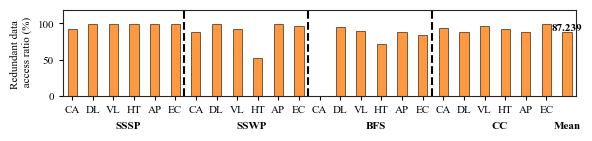

In [14]:
def plot_graph_redundant_data_access_ratio(all_data, softwareData, framework='kickstarter', hardware='base', save_path=None):

    # 准备数据
    data = []
    for algorithm in algorithms:
        algorithm_data = []
        for dataset_full, dataset_short in dataset_mapping.items():
            if dataset_short in shortdatasets:
                app_dataset_data = all_data[(all_data['Framework'] == framework) &
                                          (all_data['Hardware'] == hardware) &
                                          (all_data['Application'] == algorithm) &
                                          (all_data['Dataset'] == dataset_full)]
                software_app_dataset_data = softwareData[
                                          (softwareData['Application'] == algorithm) &
                                          (softwareData['Dataset'] == dataset_full)]
                if not app_dataset_data.empty:
                    # 计算无用数据访问比例
                    access_times = app_dataset_data['AccessTimes'].values[0]
                    updated_times = software_app_dataset_data['AccessTimes'].values[0]

                    if access_times > 0:
                        invalid_ratio = 1 - (updated_times / access_times)
                    else:
                        invalid_ratio = 0

                    algorithm_data.append(invalid_ratio * 100)

        data.append(algorithm_data)

    data = np.array(data)
    if data.ndim == 2:
        data = data[:, :, np.newaxis]   # (n_categories, n_groups, 1)

    # 使用模板
    template = GroupedBarPlotTemplate(CHART_CONFIG)
    fig, ax = template.create_grouped_plot(
        data=data,
        category_labels=algorithms,
        group_labels=shortdatasets,
        bar_labels=['Redundant access ratio'],
        colors=[CHART_CONFIG['colors']['graph']],
        ylabel='Redundant data \n access ratio (%)',
        add_mean=True,
        mean_annotation=True,
        save_path=save_path
    )

    return fig, ax

fig, ax = plot_graph_redundant_data_access_ratio(all_data, softwareData, save_path="planar_graph_redundant_data_access_ratio.pdf")

In [15]:
def collect_normalized_data(all_data, metric="ExecutionTime", base_config=('kickstarter', 'base'),
                           compare_configs = None, save_path = None):
    """
    收集性能对比数据

    Parameters:
    all_data: 完整数据集
    base_config: 基准配置 (framework, hardware)
    compare_configs: 对比配置列表 [(framework, hardware), ...]

    Returns:
    base_times: 基准数组
    compare_times_list: 对比数组列表
    """

    base_framework, base_hardware = base_config
    base_times = []
    compare_times_list = [[] for _ in range(len(compare_configs))]

    # 按算法和数据集顺序收集数据
    for algorithm in algorithms:
        for dataset_full, dataset_short in dataset_mapping.items():
            if dataset_short in shortdatasets:
                # 收集基准数据
                base_data = all_data[(all_data['Framework'] == base_framework) &
                                   (all_data['Hardware'] == base_hardware) &
                                   (all_data['Application'] == algorithm) &
                                   (all_data['Dataset'] == dataset_full)]

                if not base_data.empty:
                    base_time = base_data[metric].values[0]
                    base_times.append(base_time)

                    # 收集对比数据
                    for i, (compare_framework, compare_hardware) in enumerate(compare_configs):
                        compare_data = all_data[(all_data['Framework'] == compare_framework) &
                                              (all_data['Hardware'] == compare_hardware) &
                                              (all_data['Application'] == algorithm) &
                                              (all_data['Dataset'] == dataset_full)]

                        if not compare_data.empty:
                            compare_time = compare_data[metric].values[0]
                            compare_times_list[i].append(compare_time)
                        else:
                            compare_times_list[i].append(np.nan)
                else:
                    base_times.append(np.nan)
                    for i in range(len(compare_configs)):
                        compare_times_list[i].append(np.nan)

    # 转换为numpy数组
    base_times = np.array(base_times)
    compare_times_list = [np.array(times) for times in compare_times_list]

    # 计算归一化执行时间
    normalized_times_list = []
    for compare_times in compare_times_list:
        normalized_times = compare_times / base_times
        normalized_times_list.append(normalized_times)

    # 对数据进行reshape
    def reshape_normalized_data(normalized_times_list, n_categories, n_groups):
        """
        将归一化数据reshape为正确的形状
        """
        n_bars = len(normalized_times_list) + 1

        # 创建空的数据数组
        data = np.full((n_categories, n_groups, n_bars), np.nan)

        # 基准数据 (第一列为1)
        data[:, :, 0] = 1.0

        # 对比配置数据
        for bar_idx, normalized_times in enumerate(normalized_times_list):
            # reshape为一维数组并填充
            reshaped_data = normalized_times.reshape(n_categories, n_groups)
            data[:, :, bar_idx + 1] = reshaped_data

        return data

    n_categories = len(algorithms)
    n_groups = len(shortdatasets)
    data = reshape_normalized_data(normalized_times_list, n_categories, n_groups)
    return data

def calculate_app_gmeans(data):
    """
    计算每个应用程序的几何平均数

    Parameters:
    data: 数据矩阵 (n_algorithms, n_datasets, n_configs)

    Returns:
    app_gmeans: 每个应用程序的几何平均数矩阵 (n_algorithms, n_configs)
    """
    n_algorithms, n_datasets, n_configs = data.shape

    app_gmeans = np.zeros((n_algorithms, n_configs))

    for alg_idx in range(n_algorithms):
        for config_idx in range(n_configs):
            # 获取该算法该配置在所有数据集上的数据
            algorithm_data = data[alg_idx, :, config_idx]

            # 移除NaN值
            valid_data = algorithm_data[~np.isnan(algorithm_data)]

            if len(valid_data) > 0:
                # 计算几何平均数
                app_gmeans[alg_idx, config_idx] = gmean(valid_data)
            else:
                app_gmeans[alg_idx, config_idx] = np.nan

    return app_gmeans

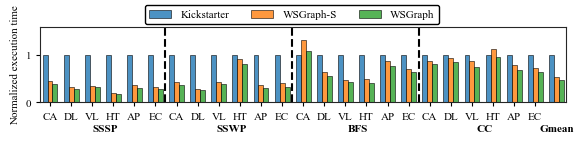

In [16]:
# 使用模板
data = collect_normalized_data(all_data, metric="ExecutionTime", base_config=('kickstarter', 'base'),
                           compare_configs=[('wsgraph', 'base'), ('wsgraph', 'graph_prefetch_4_32_2')])
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['Kickstarter', "WSGraph-S", "WSGraph"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"]],
    ylabel='Normalized execution time',
    add_gmean=True
)

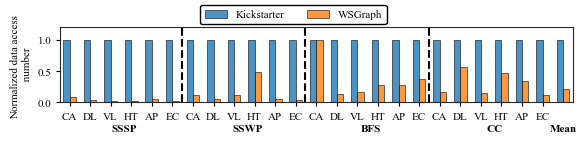

In [17]:
data = collect_normalized_data(all_data, metric="UpdatedTimes",  base_config=('kickstarter', 'base'),
                           compare_configs=[('wsgraph', 'base')])

# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['Kickstarter', "WSGraph"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"]],
    ylabel='Normalized data access \n number',
    add_mean=True,
    save_path=config["paths"]["FIGURE_DIR"] /"overallUpdatedTimes.pdf",
    # mean_annotation=True
)

In [45]:
def plot_breakdown(base_stacked, compare_stacked_list,
                           config_labels, save_path=None):
    """
    Parameters:
    base_stacked: 基准堆叠数组 (len(components), n_benchmarks+1)
    compare_stacked_list: 对比堆叠数组列表
    config_labels: 配置标签 [基准名, 对比1名, ...]
    save_path: 可选保存路径
    """
    n_algorithms, n_datasets = len(algorithms), len(shortdatasets)
    total_groups = n_algorithms * n_datasets + 1  # +1 for Gmean

    bar_width = CHART_CONFIG['bar_width']
    gap = CHART_CONFIG['group_gap']
    index = np.arange(total_groups) * ((len(compare_stacked_list) + 1) * bar_width + gap)

    fig_size = get_figure_size('single', 'single')
    fig, ax = plt.subplots(figsize=fig_size)

    # 颜色分配给组件
    colors = plt.cm.tab10.colors[:len(components)]
    hatches = [None, '///', '\\\\', 'xx']  # 不同配置区分 hatch

    # ---- 基准配置 ----
    bottoms = np.zeros(total_groups)
    for i, cat in enumerate(components):
        values = base_stacked[i]
        ax.bar(index, values, bar_width,
               bottom=bottoms, color=colors[i],
               edgecolor='black', linewidth=0.6,
               label=cat if i == 0 else None)  # 只在第一次加 legend
        bottoms += values

    # ---- 对比配置 ----
    for k, compare_stacked in enumerate(compare_stacked_list):
        bottoms = np.zeros(total_groups)
        for i, cat in enumerate(components):
            values = compare_stacked[i]
            ax.bar(index + (k+1)*bar_width, values, bar_width,
                   bottom=bottoms, color=colors[i],
                   edgecolor='black', linewidth=0.6,
                   hatch=hatches[(k+1) % len(hatches)])
            bottoms += values

    # X 轴标签
    x_labels = [f'{ds}' for alg in algorithms for ds in shortdatasets] + [""]
    ax.set_xticks(index + (len(compare_stacked_list)+1)*bar_width/2)
    ax.set_xticklabels(x_labels, rotation=0)

    # 设置 X 轴范围以消除两侧的空白
    ax.set_xlim([index[0] - bar_width, index[-1] + 2 * bar_width])

    # 算法分组标签
    for i, alg in enumerate(algorithms):
        group_center = index[i*n_datasets + n_datasets//2] + (len(compare_stacked_list)+1)*bar_width/2
        ax.text(group_center, -0.2, alg, ha='center', va='top',
                transform=ax.get_xaxis_transform(),
                fontsize=CHART_CONFIG['font_sizes']['annotation'])

    # Gmean 标签
    ax.text(index[-1] + (len(compare_stacked_list)+1)*bar_width/2, -0.2,
            "Gmean", ha='center', va='top',
            transform=ax.get_xaxis_transform(),
            fontsize=CHART_CONFIG['font_sizes']['annotation'], fontweight="bold")

    # 分割线
    for i in range(1, n_algorithms+1):
        line_pos = index[i*n_datasets] - gap
        ax.axvline(line_pos, color=CHART_CONFIG['colors']['grid'],
                   linestyle='--')

    # Y 轴
    ax.set_ylabel("Normalized energy \n consumption")
    ax.set_ylim(0, 1.2)

    # 图例
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=cat)
                       for i, cat in enumerate(components)]
    legend_elements += [
        Patch(facecolor='white', edgecolor='black', hatch=hatches[k % len(hatches)],
              label=config_labels[k]) for k in range(len(config_labels))
    ]

    ax.legend(handles=legend_elements, loc='upper center',
              bbox_to_anchor=(0.5, 1.15), ncol= 7,
              framealpha=1, edgecolor="black", handlelength=1.0,)

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.show()

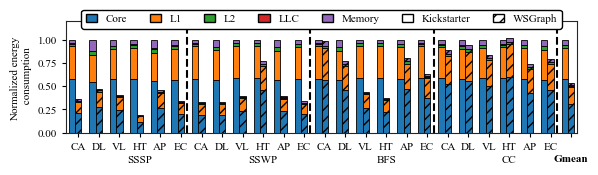

In [47]:
def prepare_energy_data(all_data,
                        base_config=('kickstarter', 'base'),
                        compare_configs=None):
    """
    收集并整理能耗对比数据 (保持 dict 存储风格，compare 归一化到 base 总功耗)

    Returns:
    base_stacked: 基准堆叠数组 (len(components), n_benchmarks+1)
    compare_stacked_list: 对比堆叠数组列表，每个元素 shape 同 base_stacked
    """

    base_framework, base_hardware = base_config
    compare_data_list = [[] for _ in range(len(compare_configs))]
    base_data = []

    # 同时记录总能耗
    base_totals = []
    compare_totals_list = [[] for _ in range(len(compare_configs))]

    # 遍历所有算法+数据集
    for algorithm in algorithms:
        for dataset_full, dataset_short in dataset_mapping.items():
            if dataset_short in shortdatasets:
                # ---- 基准配置 ----
                base_energy_row = all_data[(all_data['Framework'] == base_framework) &
                                           (all_data['Hardware'] == base_hardware) &
                                           (all_data['Application'] == algorithm) &
                                           (all_data['Dataset'] == dataset_full)]
                if not base_energy_row.empty:
                    base_energy = base_energy_row["Energy"].values[0]  # dict
                    base_data.append(base_energy)
                    base_totals.append(sum(base_energy.values()))

                    # ---- 对比配置 ----
                    for i, (cf, ch) in enumerate(compare_configs):
                        compare_row = all_data[(all_data['Framework'] == cf) &
                                               (all_data['Hardware'] == ch) &
                                               (all_data['Application'] == algorithm) &
                                               (all_data['Dataset'] == dataset_full)]
                        if not compare_row.empty:
                            compare_energy = compare_row["Energy"].values[0]
                            compare_data_list[i].append(compare_energy)
                            compare_totals_list[i].append(sum(compare_energy.values()))

    # ========== 转换为堆叠数组 ==========
    def dicts_to_array(dict_list, totals, base_totals):
        """
        把 [dict1, dict2,...] 转换成 (len(components), n_benchmarks)
        并归一化到基准配置的总能耗
        """
        arr = np.zeros((len(components), len(dict_list)))
        for j, (d, t, b) in enumerate(zip(dict_list, totals, base_totals)):
            if b == 0:
                continue
            for i, cat in enumerate(components):
                # 先取该组件能耗占比，再乘以总能耗比
                arr[i, j] = d.get(cat, 0) / t * (t / b) if t > 0 else 0
        return arr

    base_stacked = dicts_to_array(base_data, base_totals, base_totals)  # 基准归一化到自己
    compare_stacked_list = [
        dicts_to_array(lst, totals, base_totals)
        for lst, totals in zip(compare_data_list, compare_totals_list)
    ]

    # ========== 添加几何平均数 ==========
    def append_gmean(arr):
        gmeans = [gmean(arr[i, :][arr[i, :] > 0]) for i in range(arr.shape[0])]
        return np.hstack((arr, np.array(gmeans).reshape(-1, 1)))

    base_stacked = append_gmean(base_stacked)
    compare_stacked_list = [append_gmean(arr) for arr in compare_stacked_list]

    return base_stacked, compare_stacked_list


base_stacked, compare_stacked_list = prepare_energy_data(
    all_data,
    base_config=('kickstarter', 'base'),
    compare_configs=[('wsgraph', 'graph_prefetch_4_32_2')]
)
plot_breakdown(base_stacked, compare_stacked_list,
                       config_labels=['Kickstarter', 'WSGraph'], save_path="power_comparison.pdf")

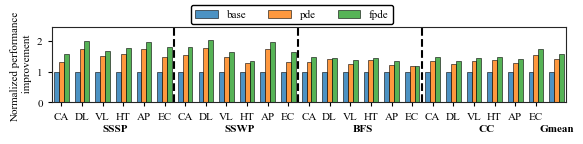

In [20]:
data = collect_normalized_data(all_data, metric="ExecutionTime",  base_config=('kickstarter', 'base'),
                           compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ("kickstarter", "graph_prefetch_with_filter_4_32_2")])
data = 1/ data
# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['base', "pde", "fpde"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"]],
    ylabel='Normalized performance \n improvement',
    add_gmean=True,
)

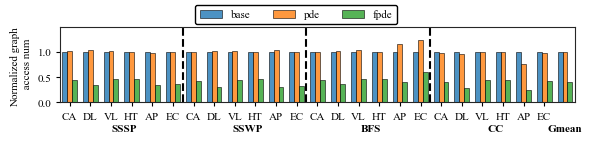

In [21]:
data = collect_normalized_data(all_data, metric="AccessTimes",  base_config=('kickstarter', 'base'),
                           compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ("kickstarter", "graph_prefetch_with_filter_4_32_2")])

# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['base', "pde", "fpde"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"]],
    ylabel='Normalized graph \n access num',
    add_gmean=True,
)

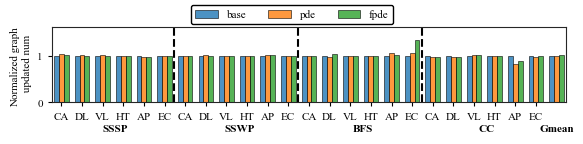

In [22]:
data = collect_normalized_data(all_data, metric="UpdatedTimes",  base_config=('kickstarter', 'base'),
                           compare_configs=[('kickstarter', 'graph_prefetch_4_32_2'), ("kickstarter", "graph_prefetch_with_filter_4_32_2")])

# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['base', "pde", "fpde"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"]],
    ylabel='Normalized graph \n updated num',
    add_gmean=True,
)

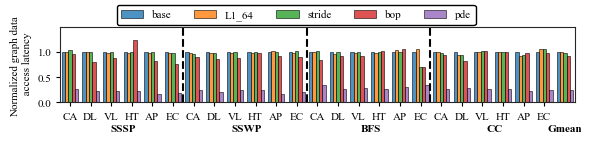

In [23]:
data = collect_normalized_data(all_data, metric="TotalGraphLoadLatency",  base_config=('kickstarter', 'base'),
                           compare_configs=[('kickstarter', 'L1_64'), ("kickstarter", "stride_prefetch"), ("kickstarter", "bop_prefetch"), ("kickstarter", "graph_prefetch_4_32_2")])

# 使用模板
template = GroupedBarPlotTemplate(CHART_CONFIG)
fig, ax = template.create_grouped_plot(
    data=data,
    category_labels=algorithms,
    group_labels=shortdatasets,
    bar_labels=['base', "L1_64", "stride", "bop", "pde"],
    colors=[CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"]],
    ylabel='Normalized graph data \n access latency',
    add_gmean=True,
)

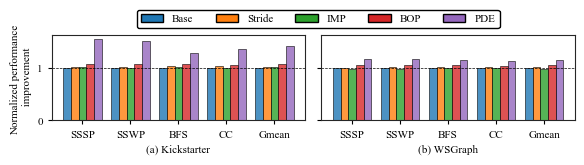

In [24]:
kickstarter_data = collect_normalized_data(all_data, metric="ExecutionTime",  base_config=('kickstarter', 'base'),
                           compare_configs=[("kickstarter", "stride_prefetch"), ("kickstarter", "imp_prefetch"), ("kickstarter", "bop_prefetch"), ("kickstarter", "graph_prefetch_4_32_2")])
wsgraph_data = collect_normalized_data(all_data, metric="ExecutionTime",  base_config=('wsgraph', 'base'),
                           compare_configs=[("wsgraph", "stride_prefetch"), ("wsgraph", "imp_prefetch"), ("wsgraph", "bop_prefetch"), ("wsgraph", "graph_prefetch_4_32_2")])

# 转换 ExecutionTime → 性能 (取倒数)
kickstarter_data = 1 / kickstarter_data
wsgraph_data = 1 / wsgraph_data

kickstarter_app_gmean = calculate_app_gmeans(kickstarter_data)
wsgraph_app_gmean = calculate_app_gmeans(wsgraph_data)

# 转置数据，使得每个配置为一组bar
kickstarter_plot_data = []
wsgraph_plot_data = []
n_algorithms, n_configs = kickstarter_app_gmean.shape
for config_idx in range(n_configs):
    kickstarter_plot_data.append(kickstarter_app_gmean[:, config_idx])
    wsgraph_plot_data.append(wsgraph_app_gmean[:, config_idx])


# 子图配置
subplot_configs = [
    {
        'data': kickstarter_plot_data,
        'labels': algorithms,
        'title': "(a) Kickstarter",
        'ylabel': 'Normalized performance \n improvement',
        'colors' : [CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"]],
        'bar_labels': ['Base', "Stride", "IMP", "BOP", "PDE"],
        'add_gmean': True,  # 启用几何平均数
        'standard_line': True  # 添加基准线
    },
    {
        'data': wsgraph_plot_data,
        'labels': algorithms,
        'title': "(b) WSGraph",
        'ylabel': '',
        'colors' : [CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"]],
        'bar_labels': ['Base', "Stride", "IMP", "BOP", "PDE"],
        'add_gmean': True,  # 启用几何平均数
        'standard_line': True  # 添加基准线
    }
]

# 图例配置
legend_config = {
    'labels': ['Base', "Stride", "IMP", "BOP", "PDE"],
    'colors': [CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"]],
    'position': 'upper center',
    'ncol': 5
}

# 使用模板
template = FlexibleSideBySidePlotTemplate()
fig, axes = template.create_side_by_side_plot(
    subplot_configs=subplot_configs,
    ncols=2,
    share_y=True,  # ✅ 共用左侧Y轴
    legend_config=legend_config,
)

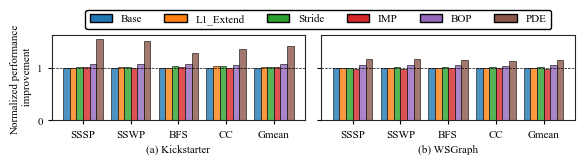

In [25]:
kickstarter_data = collect_normalized_data(all_data, metric="ExecutionTime",  base_config=('kickstarter', 'base'),
                           compare_configs=[('kickstarter', 'L1_64'), ("kickstarter", "stride_prefetch"), ("kickstarter", "imp_prefetch"), ("kickstarter", "bop_prefetch"), ("kickstarter", "graph_prefetch_4_32_2")])
wsgraph_data = collect_normalized_data(all_data, metric="ExecutionTime",  base_config=('wsgraph', 'base'),
                           compare_configs=[('wsgraph', 'L1_64'), ("wsgraph", "stride_prefetch"), ("wsgraph", "imp_prefetch"), ("wsgraph", "bop_prefetch"), ("wsgraph", "graph_prefetch_4_32_2")])

# 转换 ExecutionTime → 性能 (取倒数)
kickstarter_data = 1 / kickstarter_data
wsgraph_data = 1 / wsgraph_data

kickstarter_app_gmean = calculate_app_gmeans(kickstarter_data)
wsgraph_app_gmean = calculate_app_gmeans(wsgraph_data)

# 转置数据，使得每个配置为一组bar
kickstarter_plot_data = []
wsgraph_plot_data = []
n_algorithms, n_configs = kickstarter_app_gmean.shape
for config_idx in range(n_configs):
    kickstarter_plot_data.append(kickstarter_app_gmean[:, config_idx])
    wsgraph_plot_data.append(wsgraph_app_gmean[:, config_idx])


# 子图配置
subplot_configs = [
    {
        'data': kickstarter_plot_data,
        'labels': algorithms,
        'title': "(a) Kickstarter",
        'ylabel': 'Normalized performance \n improvement',
        'colors' : [CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"], CHART_CONFIG['colors']["config6"]],
        'bar_labels': ['Base', "L1_Extend", "Stride", "IMP", "BOP", "PDE"],
        'add_gmean': True,  # 启用几何平均数
        'standard_line': True  # 添加基准线
    },
    {
        'data': wsgraph_plot_data,
        'labels': algorithms,
        'title': "(b) WSGraph",
        'ylabel': '',
        'colors' : [CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"], CHART_CONFIG['colors']["config6"]],
        'bar_labels': ['Base', "L1_Extend", "Stride", "IMP", "BOP", "PDE"],
        'add_gmean': True,  # 启用几何平均数
        'standard_line': True  # 添加基准线
    }
]

# 图例配置
legend_config = {
    'labels': ['Base', "L1_Extend", "Stride", "IMP", "BOP", "PDE"],
    'colors': [CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"], CHART_CONFIG['colors']["config6"]],
    'position': 'upper center',
    'ncol': 6
}

# 使用模板
template = FlexibleSideBySidePlotTemplate()
fig, axes = template.create_side_by_side_plot(
    subplot_configs=subplot_configs,
    ncols=2,
    share_y=True,  # ✅ 共用左侧Y轴
    legend_config=legend_config,
    save_path= config['paths']['FIGURE_DIR'] / "l1_cache_extension_time_comparison.pdf"
)

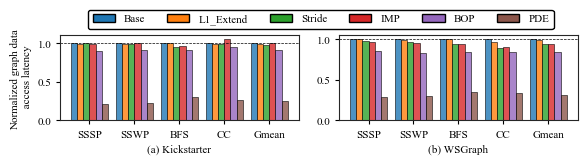

In [26]:
kickstarter_data = collect_normalized_data(all_data, metric="TotalGraphLoadLatency",  base_config=('kickstarter', 'base'),
                           compare_configs=[('kickstarter', 'L1_64'), ("kickstarter", "stride_prefetch"), ("kickstarter", "imp_prefetch"), ("kickstarter", "bop_prefetch"), ("kickstarter", "graph_prefetch_4_32_2")])
wsgraph_data = collect_normalized_data(all_data, metric="TotalGraphLoadLatency",  base_config=('wsgraph', 'base'),
                           compare_configs=[('wsgraph', 'L1_64'), ("wsgraph", "stride_prefetch"), ("wsgraph", "imp_prefetch"), ("wsgraph", "bop_prefetch"), ("wsgraph", "graph_prefetch_4_32_2")])
kickstarter_app_gmean = calculate_app_gmeans(kickstarter_data)
wsgraph_app_gmean = calculate_app_gmeans(wsgraph_data)

# 转置数据，使得每个配置为一组bar
kickstarter_plot_data = []
wsgraph_plot_data = []
n_algorithms, n_configs = kickstarter_app_gmean.shape
for config_idx in range(n_configs):
    kickstarter_plot_data.append(kickstarter_app_gmean[:, config_idx])
    wsgraph_plot_data.append(wsgraph_app_gmean[:, config_idx])


# 子图配置
subplot_configs = [
    {
        'data': kickstarter_plot_data,
        'labels': algorithms,
        'title': "(a) Kickstarter",
        'ylabel': 'Normalized graph data \n access latency',
        'colors' : [CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"], CHART_CONFIG['colors']["config6"]],
        'bar_labels': ['Base', "L1_Extend", "Stride", "IMP", "BOP", "PDE"],
        'add_gmean': True,  # 启用几何平均数
        'standard_line': True  # 添加基准线
    },
    {
        'data': wsgraph_plot_data,
        'labels': algorithms,
        'title': "(b) WSGraph",
        'ylabel': '',
        'colors' : [CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"], CHART_CONFIG['colors']["config6"]],
        'bar_labels': ['Base', "L1_Extend", "Stride", "IMP", "BOP", "PDE"],
        'add_gmean': True,  # 启用几何平均数
        'standard_line': True  # 添加基准线
    }
]

# 图例配置
legend_config = {
    'labels': ['Base', "L1_Extend", "Stride", "IMP", "BOP", "PDE"],
    'colors': [CHART_CONFIG['colors']["config1"],CHART_CONFIG['colors']["config2"],CHART_CONFIG['colors']["config3"],
            CHART_CONFIG['colors']["config4"], CHART_CONFIG['colors']["config5"], CHART_CONFIG['colors']["config6"]],
    'position': 'upper center',
    'ncol': 6
}

# 使用模板
template = FlexibleSideBySidePlotTemplate()
fig, axes = template.create_side_by_side_plot(
    subplot_configs=subplot_configs,
    ncols=2,
    legend_config=legend_config,
    save_path= config['paths']['FIGURE_DIR'] / "l1_cache_extension_latency_comparison.pdf"
)

In [ ]:
# 绘制敏感性分析图表，针对batchsize和batch的组成；原始数据不在了，因此需要重新收集数据；这部分的数据之前是使用模拟器进行收集，后续可以直接通过软件的方式进行收集

import os
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import h5py
import numpy as np
import re
import json

# Plotting
width = 430 / 72
height = width * 0.26

fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(width, height))

# Share y-axis for left axes (ax1 and ax3)
ax3.sharey(ax1)

# base directory and data collection (assuming these functions exist)
rootDir = "/home/xuanyi/research/simulator/DAMOV/simulator"
datasets = ["roadNet-CA-ungraph"]
applications = ["SSSP"]
batchSizes = [25000, 50000, 100000, 200000, 400000]
deleteRatios = [0.1]
number_of_cores = [16]
type = "ooo_nuca"

# configuration for WSGraph
deltas = [300]
buckets = [128]

baseDir = os.path.join(rootDir, "zsim_stats")
kickstarterDir = os.path.join(baseDir, "kickstarter")
baseFrame = collect_base_time(kickstarterDir)  # assuming this function exists

wsgraphDir = os.path.join(baseDir, "WSGraph")
wsgraphFrame = collect_graph_prefetch_time(wsgraphDir)  # assuming this function exists

# First plot data
batchSizes_labels = ["25K", "50K", "100K", "200K", "400K"]
algorithms = ['SSSP']
configs = ['KickStarter', 'WSGraph']
baseTimes = baseFrame['Execution Time']
wsgraphTimes = wsgraphFrame['Execution Time']

# Normalize the times
base = np.ones(len(baseTimes))
wsgraph = wsgraphTimes / baseTimes

# Define bar width and opacity
bar_width = 1
opacity = 0.8

# Calculate the positions for the bars
n_batchSizes = len(batchSizes_labels)
n_algorithms = len(algorithms)
n_configs = len(configs)
total_groups = n_algorithms * n_batchSizes
index = np.arange(total_groups) * (n_configs * bar_width + bar_width)

# First plot: Normalized Execution Time (Bar Plot)
ax1.bar(index, base, bar_width, alpha=opacity, label=configs[0], ec='black', ls='-', lw=0.5)
ax1.bar(index + bar_width, wsgraph, bar_width, alpha=opacity, label=configs[1], ec='black', ls='-', lw=0.5)

# Set x-axis and y-axis for the first plot
ax1.set_xticks(index + (n_configs - 1) * bar_width / 2)
ax1.set_xticklabels(batchSizes_labels, rotation=0)
ax1.set_ylabel('Normalized execution time')
ax1.set_xlim([index[0] - bar_width, index[-1] + (n_algorithms + 1) * bar_width])

# Create a second y-axis for ax2 (Right side)
ax2 = ax1.twinx()
# Second plot data
baseTimes_upd = baseFrame['Updated Times']
wsgraphTimes_upd = wsgraphFrame['Updated Times']
base_upd = np.ones(len(baseTimes_upd))
wsgraph_upd = wsgraphTimes_upd / baseTimes_upd

# Plot ax2 as a line
ax2.plot(index + bar_width, wsgraph_upd, color='tab:orange', marker='o', markersize=4, mew=0, label='Updated Times', linestyle='-', lw=2)

ax1.set_xlabel("(a) Batch size")

# =======================================================================================
# Second plot data
batchSizes = [100000]
deleteRatios = [0, 0.1, 0.2, 0.3, 0.4]

baseDir = os.path.join(rootDir, "zsim_stats")
kickstarterDir = os.path.join(baseDir, "kickstarter")
baseFrame_dr = collect_simulation_data(kickstarterDir)

wsgraphDir = os.path.join(baseDir, "WSGraph")
wsgraphFrame_dr = collect_graph_prefetch_time(wsgraphDir)

deleteRatio = [0, 0.1, 0.2, 0.3, 0.4]
baseTimes_dr = baseFrame_dr['Execution Time']
wsgraphTimes_dr = wsgraphFrame_dr['Execution Time']

# Normalize the times
base_dr = np.ones(len(baseTimes_dr))
wsgraph_dr = wsgraphTimes_dr / baseTimes_dr

# Calculate the positions for the bars
n_deleteRatio = len(deleteRatio)
total_groups_dr = n_algorithms * n_deleteRatio
index_dr = np.arange(total_groups_dr) * (n_configs * bar_width + bar_width)

# Third plot: Normalized Execution Time (Bar Plot)
ax3.bar(index_dr, base_dr, bar_width, alpha=opacity, label=configs[0], ec='black', ls='-', lw=0.5)
ax3.bar(index_dr + bar_width, wsgraph_dr, bar_width, alpha=opacity, label=configs[1], ec='black', ls='-', lw=0.5)

# Set x-axis for the third plot
ax3.set_xticks(index_dr + (n_configs - 1) * bar_width / 3)
ax3.set_xticklabels([f'{ds}' for ds in deleteRatio], rotation=0)
ax3.set_xlim([index_dr[0] - bar_width, index_dr[-1] + (n_algorithms + 1) * bar_width])

# Create a second y-axis for ax4 (Right side)
ax4 = ax3.twinx()

# Share y-axis with ax2
ax2.sharey(ax4)
ax2.tick_params(labelright=False, right=False)  # 不显示右侧刻度线和标签
ax2.spines['right'].set_visible(False)          # 隐藏右侧边框线

ax3.tick_params(labelleft=False, left=False)  # 不显示左侧刻度线和标签
ax3.spines['left'].set_visible(False)         # 隐藏左侧边框线


ax4.set_ylabel('Normalized access number')
# Fourth plot data
baseTimes_upd_dr = baseFrame_dr['Updated Times']
wsgraphTimes_upd_dr = wsgraphFrame_dr['Updated Times']
base_upd_dr = np.ones(len(baseTimes_upd_dr))
wsgraph_upd_dr = wsgraphTimes_upd_dr / baseTimes_upd_dr

# Plot ax4 as a line
ax4.plot(index_dr + bar_width, wsgraph_upd_dr, color='tab:orange', marker='o', markersize=4, mew=0, label='Updated Times', linestyle='-', lw=2)

ax3.set_xlabel("(b) Edge deletion ratio")

# Collect handles and labels from all axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine legends and display them as a single legend
combined_handles = handles1 + handles2
combined_labels = labels1 + labels2

fig.legend(combined_handles, combined_labels, loc='upper center', 
           ncol=len(combined_labels), bbox_to_anchor=(0.5, 1.15), edgecolor="black")
plt.savefig(os.path.join(config['paths']['FIGURE_DIR'], "Sensitive.pdf"),
            format='pdf', dpi=72, bbox_inches='tight')
plt.tight_layout()
plt.show()